# Grover's Algorithm

In [1]:
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit
import numpy as np
from qiskit_ibm_provider import IBMProvider
from qiskit.providers.ibmq import least_busy
import os

# Access to IBM
IBMQ_TOKEN = os.getenv("IBMQ_TOKEN")
provider = IBMProvider(token=IBMQ_TOKEN)

## Define the function f(x)

In [ ]:
def f(x3, x2,  x1, x0):
    return (x3 & x2 & ~x1 & x0)

## Define the oracle

In [3]:
def oracle(n=4, name='Oracle'):
    qc = QuantumCircuit(n+2+1, name=name)

    # Computation
    qc.x(1)
    qc.ccx(0,1,4)
    qc.ccx(2,3,5)
    
    # Apply the result on the last (y) qubit
    qc.ccx(4,5, 6)
    
    # Uncomputation
    qc.ccx(2,3,5)
    qc.ccx(0,1,4)
    qc.x(1)
    
    return qc.to_gate()

#oracle().draw(output="mpl", style="clifford")

## Define the diffuser

In [5]:
def diffuser(n=4, name="Diffuser"):
    qc = QuantumCircuit(n, name=name)
    
    # apply hadamard gates to all qubits
    qc.h(range(n))

    # create a NxN identity matrix
    i_mat = np.identity(2**n)

    # -1 to the x!=0 states
    for i in range(1, 2**n):
        i_mat[i,i] = -1
    qc.unitary(Operator(i_mat), range(n))
    
    # apply hadamard gates to all qubits
    qc.h(range(n))
    return qc.to_gate()


## Define Grover's algorithm circuit

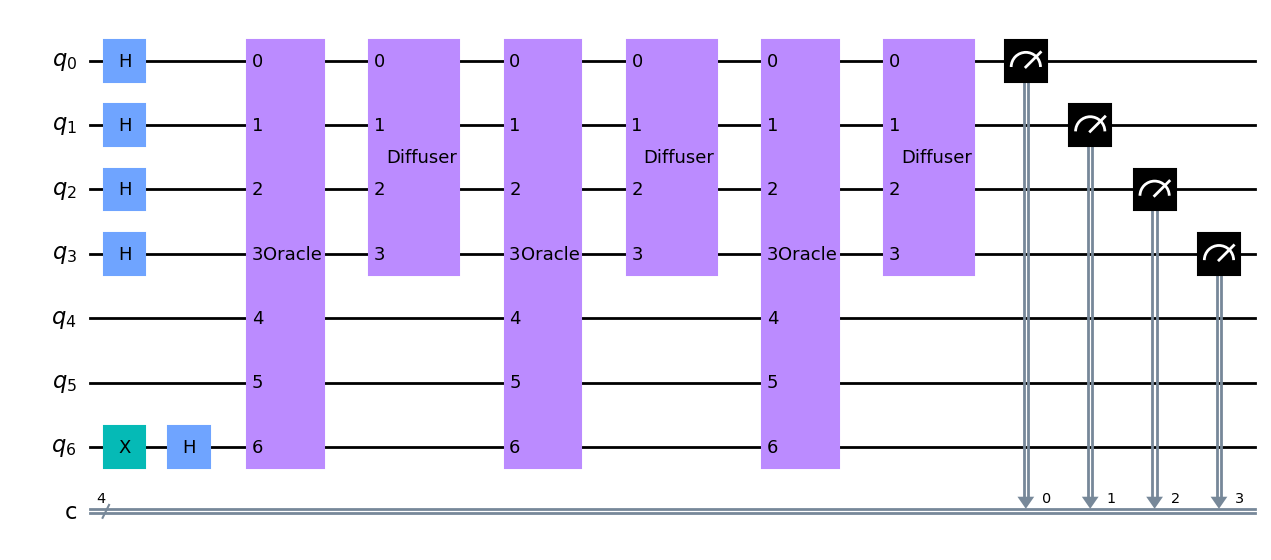

In [6]:
def grover(n=4):
    qc = QuantumCircuit(n+2+1, n)
    
    # Determine r
    r = int(np.floor(np.pi/4*np.sqrt(2**n/ 1 ))) # we know the problem has one solution
    
    # step 1: apply hadamard gates to all qubits except the last and the oracle work qubits
    qc.h(range(n))

    # Prepare the last (y) qubit to ket(-)
    qc.x(6)
    qc.h(6)
    
    # step 2: apply r rounds of the phase oracle and the diffuser
    for i in range(r):
        qc.append(oracle(n), range(n+2+1))
        qc.append(diffuser(n), range(n))
    
    # step 3: measure all qubits
    qc.measure(range(n), range(n))
  
    return qc

qc = grover(4)
qc.draw(output = 'mpl', style = 'clifford')

## Execute the circuit on the local simulator

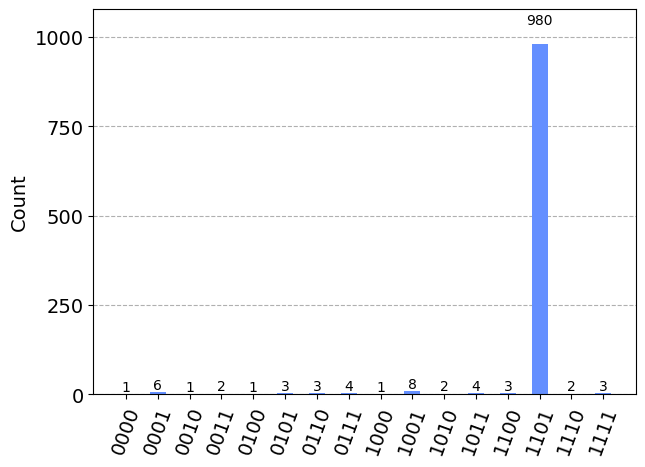

In [7]:
from qiskit import Aer, execute
simulator = Aer.get_backend('qasm_simulator')
counts = execute(qc, backend=simulator, shots=1024).result().get_counts()
from qiskit.visualization import plot_histogram
plot_histogram(counts)

## Execute the circuit on a IBM physical device

In [ ]:
shots = 1024
n = 4
# backend = least_busy(provider.backends(filters=lambda x : (x.configuration().n_qubits >= n+1 and not x.configuration().simulator and x.status().operational == True)))
backend = provider.get_backend("ibm_kyoto")
# print("Least busy backend: ", backend)
job = execute(grover(4), backend = backend, shots=shots, optimization_level = 3 )


In [ ]:
result = job.result()
counts = result.get_counts()
plot_histogram(counts)

## Check old submitted jobs

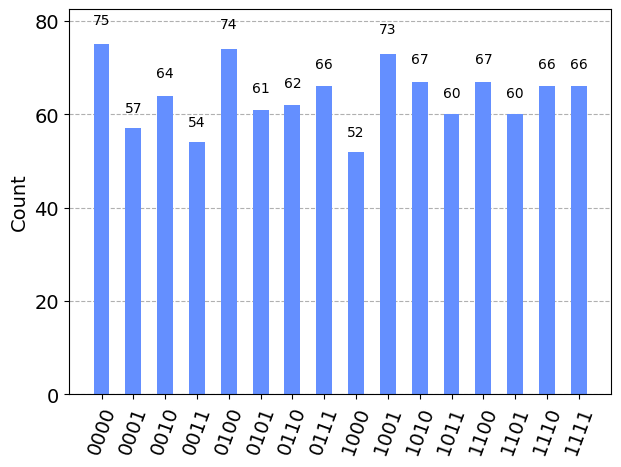

In [8]:
job1 = provider.retrieve_job("cnwrm38xtjc0008amvwg")    # The circuit showed (and executed in the simulator)
counts1 =  job1.result().get_counts()
plot_histogram(counts1)

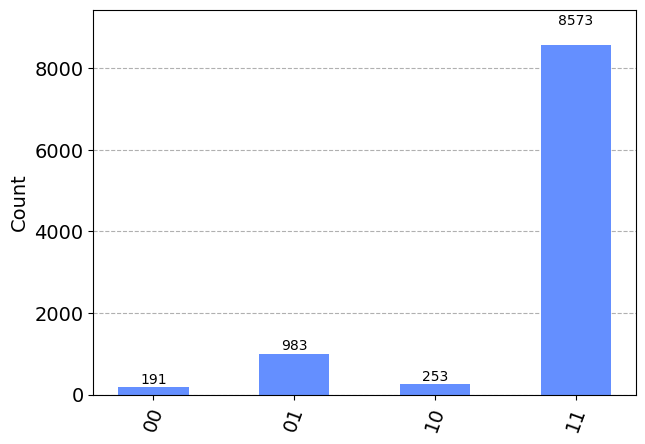

In [9]:
job2 = provider.retrieve_job("cnwvd6wxtjc0008an5n0")    # A simpler circuit that check the condition x0 & x1
counts2 =  job2.result().get_counts()
plot_histogram(counts2)